### Step 1: Import Required Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Step 2: Read Image

In [2]:
image = cv2.imread('./data/digits1.png')

In [3]:
image.shape

(1000, 2000, 3)

In [5]:
gray_img = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

In [6]:
gray_img.shape

(1000, 2000)

### Step 3: Split Image and Preparing Data

In [52]:
divisions = list(np.hsplit(i, 100) for i in np.vsplit(gray_img, 50))

In [53]:
dataset = np.array(divisions)

In [54]:
dataset.shape

(50, 100, 20, 20)

In [68]:
train_data = dataset[:,:50].reshape(-1,400).astype(np.float32) 
test_data = dataset[:,50:100].reshape(-1,400).astype(np.float32) 

In [58]:
k = np.arange(10) 
train_labels = np.repeat(k,250)[:,np.newaxis] 
test_labels = np.repeat(k,250)[:,np.newaxis] 

In [66]:
print('data shape:', train_data.shape)
print('label shape:', train_labels.shape)

data shape: (2500, 400)
label shape: (2500, 1)


In [59]:
def showInfo(i):
    print(f'label is {train_labels[i][0]}')
    plt.imshow(train_data[i].reshape(20, 20))

label is 4


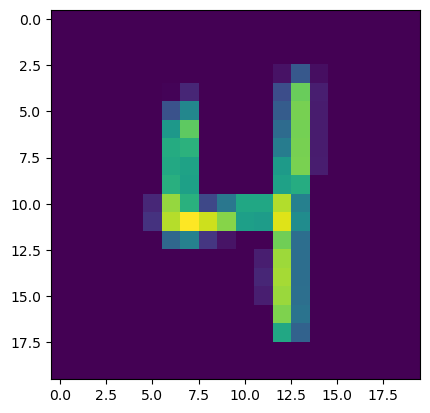

In [64]:
showInfo(1010)

### Step 4: Define the Model

In [65]:
knn = cv2.ml.KNearest_create() 

In [69]:
knn.train(train_data, cv2.ml.ROW_SAMPLE, train_labels)

True

### Step 5: prediction

In [86]:
ret, output ,neighbours, distance = knn.findNearest(test_data, k = 3)

In [87]:
matched = output==test_labels
correct_OP = np.count_nonzero(matched) 
accuracy = (correct_OP*100.0)/(output.size)
print('accuracy:', accuracy)

accuracy: 91.64


In [ ]:
cv2.kmeans()